In [272]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, nbinom, pearsonr


def generate_gram_hub_matrix(n, alpha, shape, hub_probability, seed=42):
    # A will be our 'loading' matrix: (n_variables x n_factors)
    # We start with an Identity part to ensure each gene has unique variance (noise)
    # This guarantees the matrix is PD, not just PSD.
    np.random.seed(seed)
    A = np.eye(n) * np.sqrt(1 - alpha)

    remaining_vars = n
    current_idx = 0
    hubs = []

    # 1. Add Cluster Factors
    while remaining_vars > 0:
        size = int((np.random.pareto(shape) + 1))
        size = max(1, min(size, remaining_vars)) # Constrain to total N
        idx_set = np.arange(current_idx, current_idx + size)

        # Create a new column for this cluster factor
        cluster_col = np.zeros((n, 1))
        strength = np.random.uniform(0.1 * alpha, alpha)
        cluster_col[idx_set] = np.sqrt(strength)

        A = np.hstack([A, cluster_col])

        # Save a hub for later
        hubs.append(np.random.choice(idx_set))

        current_idx += size
        remaining_vars -= size

    # 2. Add Hub Factors (Inter-cluster connections)
    # We create a single 'global' factor that only hubs listen to
    global_hub_col = np.zeros((n, 1))
    for h_idx in hubs:
        if np.random.rand() < hub_probability:
            # Random weight (can be negative)
            weight = np.random.uniform(-alpha, alpha)
            global_hub_col[h_idx] = weight

    A = np.hstack([A, global_hub_col])

    # 3. Generate the Matrix
    # Covariance C = A * A.T
    C = A @ A.T

    # 4. Normalize to Correlation Matrix (1s on diagonal)
    d = np.sqrt(np.diag(C))
    R = C / np.outer(d, d)

    return R
def plot_ccdf(data, label=None):
    # 1. Sort the data in ascending order
    sorted_data = np.sort(data)

    # 2. Calculate the CDF values (from 1/N to 1)
    # n is the number of data points
    n = len(sorted_data)
    cdf = np.arange(1, n + 1) / n

    # 3. Calculate the CCDF (1 - CDF)
    # We use (n - i) / n to avoid the last point being 0,
    # which can't be plotted on a log scale.
    ccdf = 1 - cdf + (1/n)

    # 4. Plotting
    plt.loglog(sorted_data, ccdf, marker='.', linestyle='none', label=label)
    plt.xlabel('Value (log)')
    plt.ylabel('P(X > x) (log)')
    plt.title('Complementary CDF (Log-Log Scale)')
    plt.grid(True, which="both", ls="-", alpha=0.5)
def simulate_scRNA_data(n_cells=1000, n_genes=2000, sigma = None, rho=0.9, dropout_rate=2):
    # 1. Create a Block-Diagonal Covariance Matrix
    if sigma is None:
        sigma = generate_gram_hub_matrix(n_genes, rho, 1.5, 0.2, seed=31)
    # 2. Generate Correlated Multivariate Normal Data (Latent Space)
    mu_vec = np.zeros(n_genes)
    latent_data = np.random.multivariate_normal(mu_vec, sigma, size=n_cells)

    # 3. Map to Uniform via Normal CDF
    # This "unpiles" the bell curve into a flat [0, 1] range
    uniform_data = norm.cdf(latent_data)

    # 4. Map to Negative Binomial (Counts)
    # We'll assign each gene a mean (mu) and a dispersion (r)
    # High dispersion (low r) makes the data "noisier"
    counts = np.zeros_like(uniform_data)
    for i in range(n_genes):
        # Parameters
        shape = 1.5
        scale = 0.01  # This is the scale of the Inverse Gamma

        # Step 1: Draw from Gamma (use 1/scale because NumPy uses 'theta' scale)
        # Step 2: Invert the result
        gene_mu = 1.0 / np.random.default_rng().gamma(shape, 1.0/scale, 1)
        gene_r = 0.5 # Common dispersion for scRNA-seq

        # Calculate NB parameters (n, p) from (mu, r)
        # n = r, p = r / (r + mu)
        p_param = gene_r / (gene_r + gene_mu)
        counts[:, i] = nbinom.ppf(uniform_data[:, i], gene_r, p_param)

    # add cell total expression variability:
    cell_amp = np.random.lognormal(0.5,1,n_cells)
    cell_amp = np.maximum(cell_amp, 0)

    # Reshape v to (p, 1) then tile it n times
    cell_amp = np.tile(cell_amp[:, np.newaxis], (1, n_genes))
    counts = np.round(cell_amp * counts)
    # 5. Model Dropouts (Expression-dependent)
    # Probability of dropout is higher for lower counts
    # Using a simple exponential decay: P(dropout) = exp(-0.1 * count)
    dropout_prob = np.exp(-dropout_rate * counts)
    mask = np.random.rand(*counts.shape) > dropout_prob
    observed_counts = counts * mask

    return counts, observed_counts

In [295]:

# --- Execution and Visualization ---
n_genes = 2000
rho=0.9
sigma = generate_gram_hub_matrix(n_genes, rho, 1.5, 0.2, seed=31)

(1000, 2000)
max ev: 18.55795203968373, number above threshold: 17
max scrambled ev: 6.274742027155959
zero fraction: 0.989298


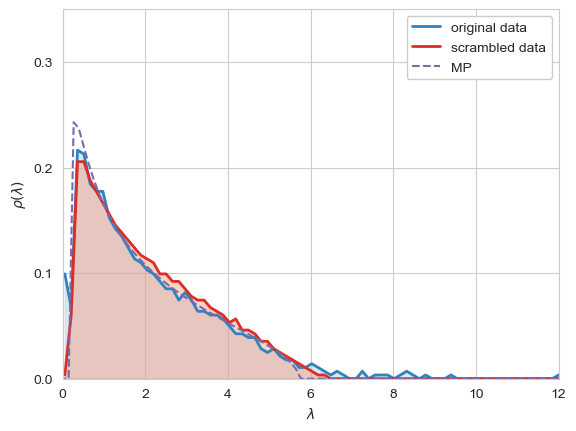

In [297]:
true_counts, observed_counts = simulate_scRNA_data(n_genes=n_genes, sigma=sigma, dropout_rate=1)

import utils
import importlib
importlib.reload(utils)
pcs, pcs1 = utils.get_eig_dist(observed_counts, norm=True, log=False, norm_sum=100)
print(observed_counts.shape)
utils.plot_eig_dist(pcs,pcs1,observed_counts.shape[0],12,0.35,80)
print(f'max ev: {np.max(pcs)}, number above threshold: {sum(pcs>np.max(pcs1))}')
print(f'max scrambled ev: {np.max(pcs1)}')
print(f'zero fraction: {sum(sum(observed_counts==0))/(len(observed_counts.flatten()))}')

plt.show()

In [263]:
np.save('simulated_pcs_1.npy',[pcs,pcs1])

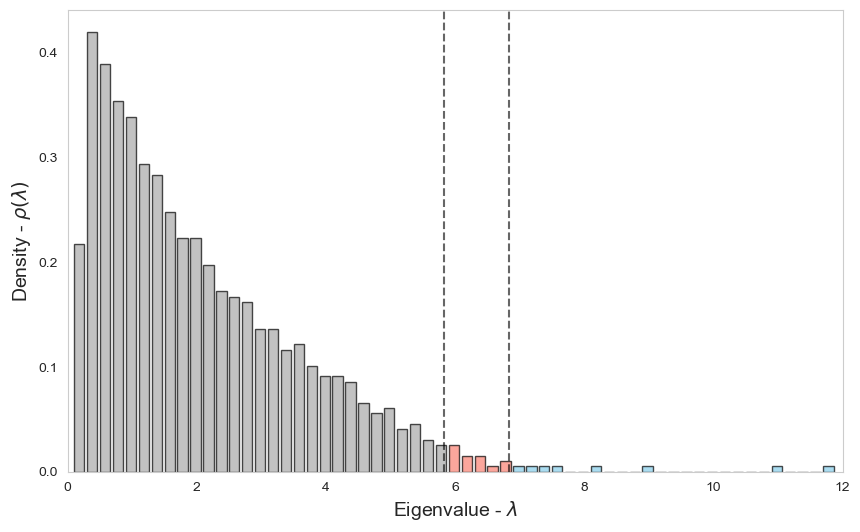

In [230]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate data
data1 = pcs
data2 = pcs1

x1 = (1+np.sqrt(2))**2 #MP limit
x2 = np.max(pcs1)
bin_width = 0.2
all_data = np.concatenate([data1, data2])
bin_edges = np.arange(min(all_data), max(all_data) + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot Dataset 1 (making bars slightly thinner than the bin width)
n1, bins1, patches1 = ax.hist(data1, bins=bin_edges, width=bin_width*0.8, align='right',
                              edgecolor='black',color='#d9d9d9', alpha=0.7, density=True)

# 3. Plot Dataset 2 (shifting its bin edges forward so they sit side-by-side/overlap)
#n2, bins2, patches2 = ax.hist(data2, bins=bin_edges + (bin_width * 0.5), width=bin_width * 0.5,
#                              edgecolor='black', color='#737373', alpha=0.7, label='Dataset 2')

# 4. Color Dataset 1 (Standard solid colors)
for patch in patches1:
    bin_x = patch.get_x()
    if bin_x < x1:
        patch.set_facecolor('darkgray')
    elif x1 <= bin_x < x2:
        patch.set_facecolor('salmon')
    else:
        patch.set_facecolor('skyblue')


# 6. Add thresholds and layout elements
ax.axvline(x1, color='k', linestyle='--', alpha=0.6)
ax.axvline(x2, color='k', linestyle='--', alpha=0.6)

ax.set_xlabel(r"Eigenvalue - $\lambda$", fontsize=14)
ax.set_ylabel(r"Density - $\rho(\lambda)$", fontsize=14)
ax.set_yticks([0,0.1,0.2,0.3,0.4])
ax.grid(False)
ax.set_xlim([bin_edges[0], bin_edges[-1]+bin_width])
plt.show()

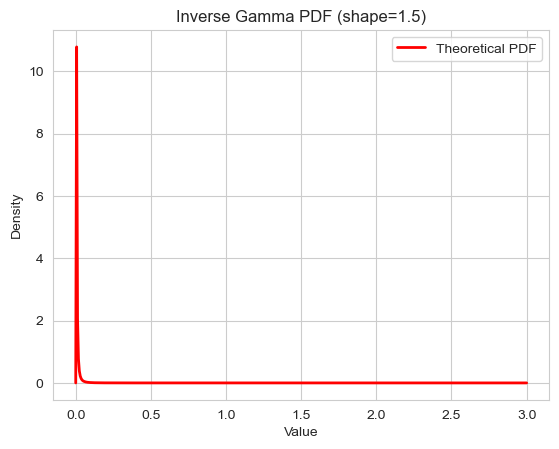

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Parameters
a = 1.5  # Shape
scale = 0.001
x = np.linspace(0, 3, 500) # Range of x-axis

# Calculate the PDF
pdf = invgamma.pdf(x, a, scale = scale)

plt.plot(x, pdf, 'r-', lw=2, label='Theoretical PDF')
plt.title(f"Inverse Gamma PDF (shape={a})")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

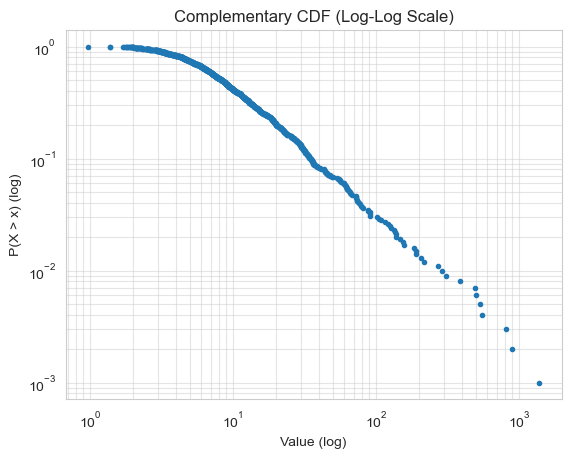

In [168]:
shape = 1.5
scale = 0.01
# This is the scale of the Inverse Gamma

# Step 1: Draw from Gamma (use 1/scale because NumPy uses 'theta' scale)
# Step 2: Invert the result
gene_mu = 1.0 / np.random.default_rng().gamma(shape, 1.0/scale, 1000)
plot_ccdf(gene_mu * 1000)
plt.show()

40
2000


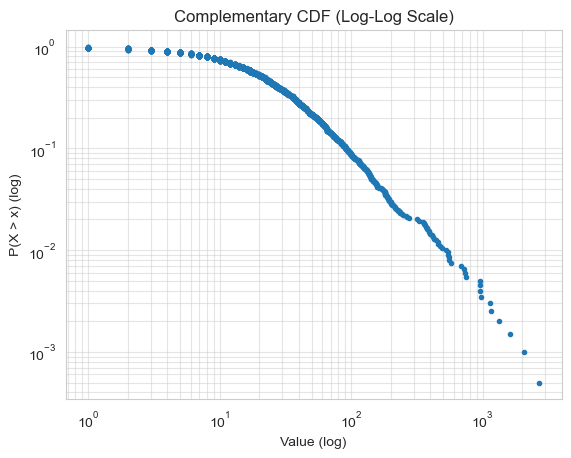

In [189]:
gene_mu = np.sum(observed_counts, axis=0)
plot_ccdf(gene_mu)
print(np.sum(gene_mu==0))
print(len(gene_mu))